In [91]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [92]:
# 1. Cargar los datasets procesados
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

# 2. Separar características (X) y etiquetas (y)
X_train = train_df.drop(columns=['target']).values
y_train = train_df['target'].values

X_test = test_df.drop(columns=['target']).values
y_test = test_df['target'].values

# Guardamos el número de variables de entrada para definir la primera capa
num_features = X_train.shape[1]

# Convertir etiquetas a one-hot encoding (necesario para categorical_crossentropy)
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

In [93]:
X_train.shape

(1120, 18)

In [94]:
# 3. Construcción del Modelo Inicial
model = Sequential()
num_neuronas = X_train.shape[1]
num_neuronas_salida = 4

# Capas ocultas
model.add(Dense(units=num_neuronas, activation='relu'))
model.add(Dense(units=num_neuronas, activation='relu'))
model.add(Dense(num_neuronas_salida, activation='softmax'))  # Softmax para multiclase

# Compilación para clasificación multiclase
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['categorical_accuracy'])

In [95]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)

In [96]:
# Convertir Y a formato categórico si fuera necesario (Por ejemplo, clasificadores multiclase)
# Entrenar el modelo
model.fit(x=X_train,
          y=y_train_cat,
          epochs=200,
          batch_size=256,
          validation_data=(X_test, y_test_cat), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - categorical_accuracy: 0.1286 - loss: 1.4339 - val_categorical_accuracy: 0.1400 - val_loss: 1.4078
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - categorical_accuracy: 0.2036 - loss: 1.3489 - val_categorical_accuracy: 0.2400 - val_loss: 1.3221
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - categorical_accuracy: 0.2937 - loss: 1.2731 - val_categorical_accuracy: 0.3050 - val_loss: 1.2471
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - categorical_accuracy: 0.3696 - loss: 1.2056 - val_categorical_accuracy: 0.3700 - val_loss: 1.1807
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - categorical_accuracy: 0.4437 - loss: 1.1458 - val_categorical_accuracy: 0.5050 - val_loss: 1.1212
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - categorical_accuracy: 0.5009 - loss: 1.0911 - val_categorical_accuracy: 0.5600 - val_loss: 1.0672
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - categorical_accuracy: 0.5562 - loss: 1.0413 - v

<Axes: >

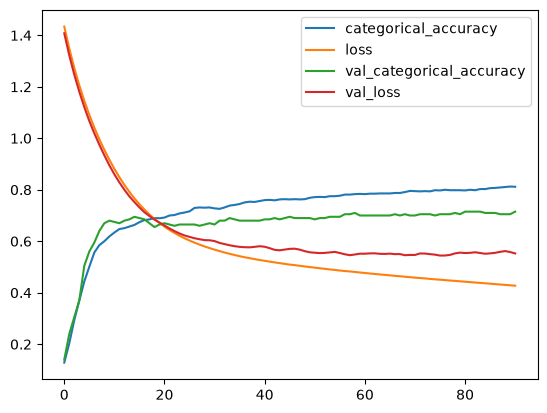

In [100]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## 1. Variables de Pérdida (Loss / El Error)
### Pérdida de Entrenamiento (loss - Línea Naranja):
Entre mas bajas esten las lineas es mejor ya que miden el margen de error
### Pérdida de Validación (val_loss - Línea Roja):
Mide el error del modelo
## Variables de Precisión (Accuracy / El Acierto)
### Precisión de Entrenamiento (categorical_accuracy - Línea Azul):
El porcentaje de estudiantes clasificados
### Precisión de Validación (val_categorical_accuracy - Línea Verde):
El porcentaje real de aciertos cuando el modelo se enfrenta a situaciones del mundo real

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Confusion matrix sin normalizar
[[102  38   0   0]
 [ 16  44   0   0]
 [  0   0   0   0]
 [  0   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

  Sin riesgo       0.86      0.73      0.79       140
 Riesgo bajo       0.54      0.73      0.62        60
Riesgo medio       0.00      0.00      0.00         0
 Riesgo alto       0.00      0.00      0.00         0

    accuracy                           0.73       200
   macro avg       0.35      0.37      0.35       200
weighted avg       0.77      0.73      0.74       200



C:\Users\johel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\johel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\johel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

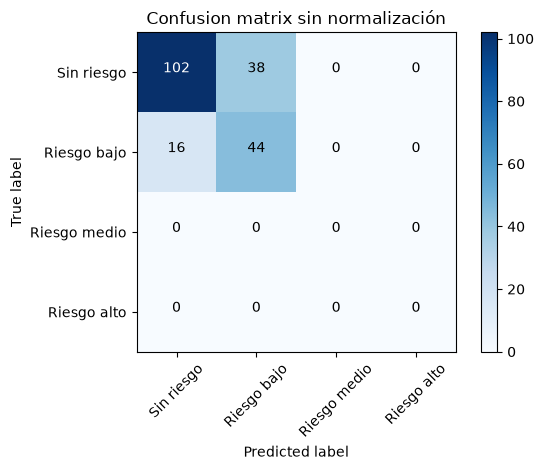

In [86]:
from sklearn.metrics import classification_report, confusion_matrix

## 8.1 Predicción sobre el conjunto de Test
predictions = model.predict(X_test)

y_test_cat

predictions

#predictions_lab = model.predict_classes(X_test)
predictions_lab = np.argmax(model.predict(X_test), axis=-1)  # Si nueva versión de scikit-learn

predictions_lab  # La etiqueta 0 es la primera categoría de la variable objetivo y así sucesivamente

predictions_lab_real = predictions_lab + 1

predictions_lab_real

# Dataframe con las 4 variables de riesgo académico
df_test_lab = pd.DataFrame(y_test_cat, columns=['Sin riesgo', 'Riesgo bajo', 'Riesgo medio', 'Riesgo alto'])

df_test_lab

df_test_lab["Clase Real"] = np.where(df_test_lab["Sin riesgo"] == 1, 1,
                            np.where(df_test_lab["Riesgo bajo"] == 1, 2,
                            np.where(df_test_lab["Riesgo medio"] == 1, 3, 4)))

df_test_lab["Clase Real"]

clases = [1, 2, 3, 4]
nombres_clases = ['Sin riesgo', 'Riesgo bajo', 'Riesgo medio', 'Riesgo alto']

array_clase_real = df_test_lab["Clase Real"].to_numpy()

confusion_matrix(array_clase_real, predictions_lab_real, labels=clases)


def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    Source: https://datascience.stackexchange.com/questions/40067/confusion-matrix-three-classes-python/40068
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix sin normalizar')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cnf_matrix = confusion_matrix(array_clase_real, predictions_lab_real, labels=clases)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=nombres_clases,
                      title='Confusion matrix sin normalización')

# Classification report
print("\nClassification Report:")
# Se mapean los vectores reales y predichos ajustados de 0 a 3 para compatibilidad nativa con classification_report
y_true_report = np.argmax(y_test_cat, axis=1)

# Agregamos labels=[0, 1, 2, 3] para que Scikit-Learn sepa que son 4 clases fijas
print(classification_report(y_true_report, predictions_lab, labels=[0, 1, 2, 3], target_names=nombres_clases))

In [87]:
# 9.Monitorización con Tensorboard
from tensorflow.keras.callbacks import TensorBoard

log_directory = 'logs\\fit'

board = TensorBoard(log_dir=log_directory, histogram_freq=1,
                    write_graph=True,
                    write_images=True,
                    update_freq='epoch',
                    profile_batch=2,
                    embeddings_freq=1)

In [88]:
## 9.1 Entrenamiento del modelo
model = Sequential()

num_neuronas = X_train.shape[1]
num_neuronas_salida = 4

# Primera capa oculta
model.add(Dense(units=num_neuronas, activation='relu'))

# Segunda capa oculta (CORREGIDA con // para evitar decimales)
model.add(Dense(units=num_neuronas // 2, activation='relu'))

# Capa de salida (Con activación Softmax para las 4 clases de riesgo académico)
model.add(Dense(units=num_neuronas_salida, activation='softmax'))

# Compilación (CORREGIDA sin el espacio extra al inicio)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['categorical_accuracy'])

model.fit(x=X_train,
          y=y_train_cat,
          epochs=200,
          batch_size=256,
          validation_data=(X_test, y_test_cat), verbose=1,
          callbacks=[early_stop, board] #Añadimos el callback para monitorizar con tensorboard
          )

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - categorical_accuracy: 0.1187 - loss: 1.8491 - val_categorical_accuracy: 0.1700 - val_loss: 1.7480
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - categorical_accuracy: 0.1429 - loss: 1.7609 - val_categorical_accuracy: 0.1950 - val_loss: 1.6597
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - categorical_accuracy: 0.1741 - loss: 1.6813 - val_categorical_accuracy: 0.2200 - val_loss: 1.5791
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - categorical_accuracy: 0.1973 - loss: 1.6099 - val_categorical_accuracy: 0.2350 - val_loss: 1.5051
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - categorical_accuracy: 0.2196 - loss: 1.5443 - val_categorical_accuracy: 0.3000 - val_loss: 1.4382
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - categorical_accuracy: 0.2446 - loss: 1.4855 - val_categorical_accuracy: 0.3450 - val_loss: 1.3775
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - categorical_accuracy: 0.2741 - loss: 1.4311